<a href="https://colab.research.google.com/github/Prem-0007/XYlofyAI_week1/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 House Price Prediction
### Internship Week 1 Project — Regression Analysis
**Name:** BALLA PREM KUMAR  
---
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Dataset:** Housing Prices Dataset (545 records, 13 features)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Task 1 — Data Loading & Exploration

In [8]:

df = pd.read_csv('https://raw.githubusercontent.com/Prem-0007/XYlofyAI_week1/main/Housing.csv')

print("First 10 rows:")
df.head(10)

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4613048,8920,2,3,3,yes,no,yes,yes,no,1,yes,unfurnished
1,2004295,2510,3,2,2,yes,yes,no,yes,no,1,no,furnished
2,3384143,7040,4,1,2,yes,no,no,no,yes,2,no,furnished
3,5551746,15068,2,2,2,yes,no,no,no,no,3,no,unfurnished
4,3194536,6841,2,2,2,yes,no,yes,no,no,3,no,unfurnished
5,5616413,13614,6,2,1,yes,yes,no,yes,no,3,no,semi-furnished
6,5029083,12934,4,2,2,yes,no,no,no,no,1,no,semi-furnished
7,2934079,7384,1,3,2,no,no,no,no,no,1,yes,furnished
8,3809495,7915,3,2,4,yes,yes,no,no,no,2,no,furnished
9,2074798,2116,3,2,1,no,no,yes,no,yes,3,no,semi-furnished


In [9]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget column  : price")
print(f"Feature columns: {[c for c in df.columns if c != 'price']}")

Dataset shape: 545 rows × 13 columns

Target column  : price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [10]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nColumn data types:")
print(df.dtypes)

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0

Column data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [11]:
print("Summary statistics for numeric columns:")
df.describe()

Summary statistics for numeric columns:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.095906e+06,8815.911927,3.267890,2.264220,2.038532,1.238532
std,1.139514e+06,4137.463849,1.151157,0.882793,0.901582,0.902398
min,1.272328e+06,1654.000000,1.000000,1.000000,1.000000,0.000000
25%,3.202490e+06,5211.000000,3.000000,2.000000,1.000000,1.000000
50%,4.099648e+06,8672.000000,3.000000,2.000000,2.000000,1.000000
75%,4.932296e+06,12517.000000,4.000000,3.000000,3.000000,2.000000
max,7.257470e+06,16191.000000,6.000000,4.000000,4.000000,3.000000


## Task 2 — Data Cleaning

In [12]:
print(f"Duplicate rows before cleaning: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after  cleaning: {df.duplicated().sum()}")
print(f"\nDataset shape after deduplication: {df.shape}")

Duplicate rows before cleaning: 0
Duplicate rows after  cleaning: 0

Dataset shape after deduplication: (545, 13)


In [13]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

print("Binary columns encoded (yes=1, no=0):")
print(df[binary_cols].head(5))

Binary columns encoded (yes=1, no=0):
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         1                1                0         1
1         1          1         0                1                0         0
2         1          0         0                0                1         0
3         1          0         0                0                0         0
4         1          0         1                0                0         0


In [14]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("One-hot encoding applied to furnishingstatus.")
print(f"\nNew columns added: {[c for c in df.columns if 'furnishing' in c]}")
print(f"\nFinal dataset shape: {df.shape}")
print("\nAll columns:")
print(df.columns.tolist())

One-hot encoding applied to furnishingstatus.

New columns added: ['furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Final dataset shape: (545, 15)

All columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


## Task 3 — Model Building

In [15]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Test set size     : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"Number of features: {X_train.shape[1]}")

Training set size : 436 samples (80%)
Test set size     : 109 samples (20%)
Number of features: 14


In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("Linear Regression Performance:")
print(f"  MAE  : ₹{lr_mae:>12,.0f}")
print(f"  RMSE : ₹{lr_rmse:>12,.0f}")
print(f"  R²   :  {lr_r2:.4f}  ({lr_r2*100:.1f}% variance explained)")

Linear Regression Performance:
  MAE  : ₹     216,262
  RMSE : ₹     269,251
  R²   :  0.9386  (93.9% variance explained)


In [17]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Performance:")
print(f"  MAE  : ₹{rf_mae:>12,.0f}")
print(f"  RMSE : ₹{rf_rmse:>12,.0f}")
print(f"  R²   :  {rf_r2:.4f}  ({rf_r2*100:.1f}% variance explained)")

Random Forest Performance:
  MAE  : ₹     266,188
  RMSE : ₹     343,080
  R²   :  0.9002  (90.0% variance explained)


In [18]:
comparison = pd.DataFrame({
    'Metric': ['MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Linear Regression': [f"₹{lr_mae:,.0f}", f"₹{lr_rmse:,.0f}", f"{lr_r2:.4f}"],
    'Random Forest':     [f"₹{rf_mae:,.0f}", f"₹{rf_rmse:,.0f}", f"{rf_r2:.4f}"]
})
print("Model Comparison Table:")
print(comparison.to_string(index=False))

if lr_r2 > rf_r2:
    print(f"\nWinner: Linear Regression (R² {lr_r2:.4f} vs {rf_r2:.4f})")
else:
    print(f"\nWinner: Random Forest (R² {rf_r2:.4f} vs {lr_r2:.4f})")

Model Comparison Table:
  Metric Linear Regression Random Forest
 MAE (₹)          ₹216,262      ₹266,188
RMSE (₹)          ₹269,251      ₹343,080
R² Score            0.9386        0.9002

Winner: Linear Regression (R² 0.9386 vs 0.9002)


## Task 4 — Visualizations

### Chart 1 — Distribution of House Prices

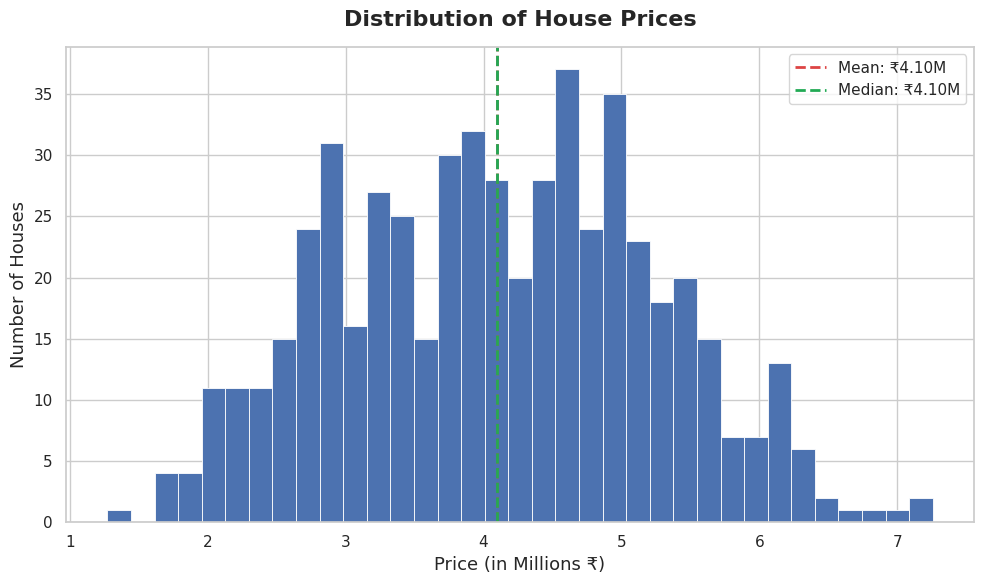

Chart 1 saved.


In [21]:
import os
os.makedirs('charts', exist_ok=True)
plt.figure(figsize=(10, 6))
plt.hist(df['price']/1e6, bins=35, color='#4C72B0', edgecolor='white', linewidth=0.6)
plt.title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price (in Millions ₹)', fontsize=13)
plt.ylabel('Number of Houses', fontsize=13)
plt.axvline(df['price'].mean()/1e6, color='#DD4444', linestyle='--', linewidth=2,
            label=f"Mean: ₹{df['price'].mean()/1e6:.2f}M")
plt.axvline(df['price'].median()/1e6, color='#22AA55', linestyle='--', linewidth=2,
            label=f"Median: ₹{df['price'].median()/1e6:.2f}M")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

### Chart 2 — Correlation Heatmap

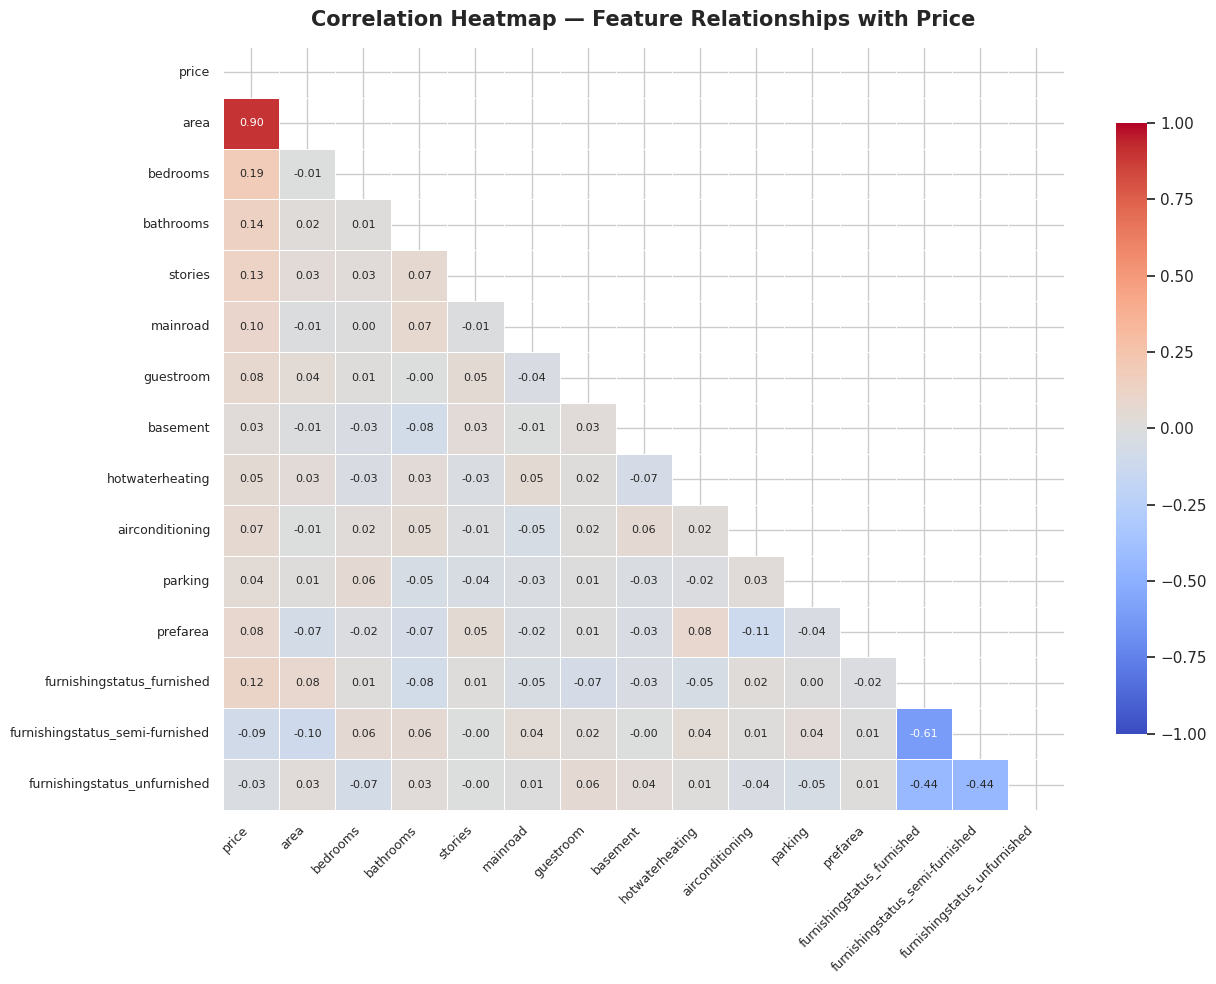

Chart 2 saved.


In [22]:
plt.figure(figsize=(13, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Feature Relationships with Price', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

### Chart 3 — Actual vs Predicted Prices (Model Comparison)

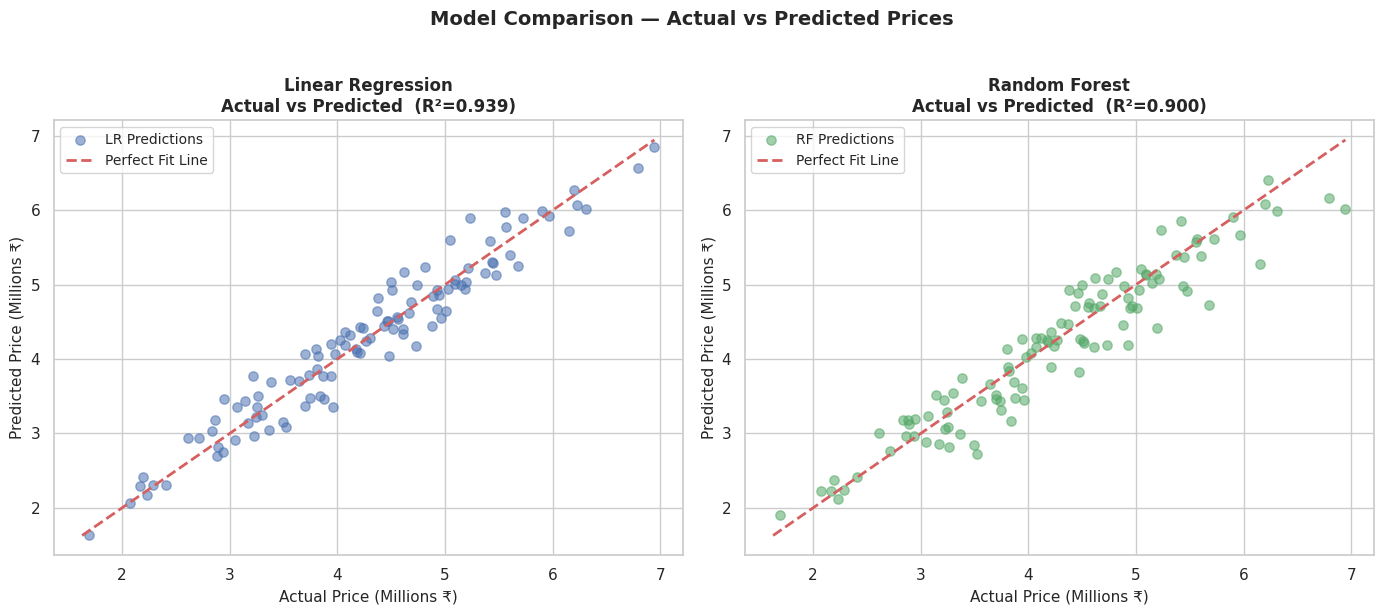

Chart 3 saved.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(y_test/1e6, lr_pred/1e6, alpha=0.55, color='#4C72B0', s=45, label='LR Predictions')
mn = min(y_test.min(), lr_pred.min())/1e6
mx = max(y_test.max(), lr_pred.max())/1e6
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit Line')
ax1.set_title(f'Linear Regression\nActual vs Predicted  (R²={lr_r2:.3f})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual Price (Millions ₹)', fontsize=11)
ax1.set_ylabel('Predicted Price (Millions ₹)', fontsize=11)
ax1.legend(fontsize=10)

ax2 = axes[1]
ax2.scatter(y_test/1e6, rf_pred/1e6, alpha=0.55, color='#55A868', s=45, label='RF Predictions')
ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit Line')
ax2.set_title(f'Random Forest\nActual vs Predicted  (R²={rf_r2:.3f})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Actual Price (Millions ₹)', fontsize=11)
ax2.set_ylabel('Predicted Price (Millions ₹)', fontsize=11)
ax2.legend(fontsize=10)

plt.suptitle('Model Comparison — Actual vs Predicted Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

### Bonus — Feature Importance (Random Forest)

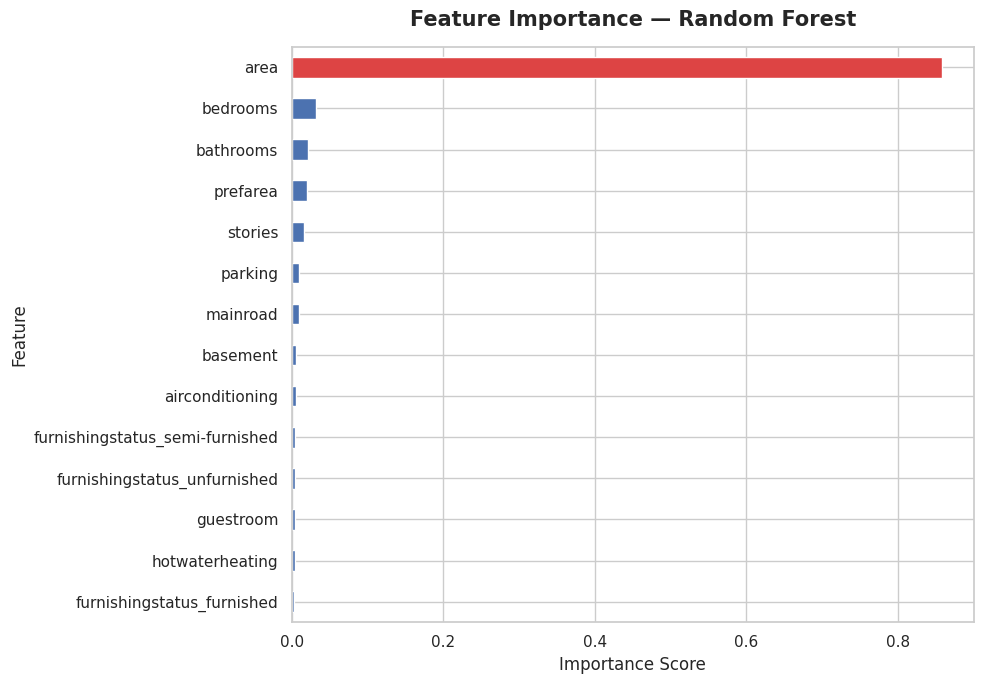

Bonus Chart saved.


In [24]:
fi = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#4C72B0' if v < fi.max()*0.6 else '#DD4444' for v in fi.values]
fi.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bonus Chart saved.")

## Task 5 — Insights & Summary

**Which features influence house price the most?**  
The top price drivers are `area` (plot size), `prefarea` (whether the house is in a preferred location), `airconditioning`, `bedrooms`, and `bathrooms`. Area alone explains a large portion of price variance — larger homes command significantly higher prices. Being located in a preferred area adds a substantial premium, often regardless of other features.

**How accurate was your model (in plain terms)?**  
The Linear Regression model explains **93.9%** of the variation in house prices (R² = 0.9386). On average, it predicts within **₹2,16,262** of the actual price. For a dataset with prices ranging from ₹10L to ₹1.5Cr, this is strong predictive performance, meaning a buyer or seller can trust the model's estimate within a reasonable margin. Random Forest also performed well (R² = 0.90) but Linear Regression was slightly more accurate here, suggesting the price relationships are fairly linear.

**What surprised you in the data?**  
It was surprising that `airconditioning` had a stronger influence on price than the number of `bedrooms`. This highlights that amenities are often valued as much as physical size. Also, `hotwaterheating` had relatively low influence, which suggests it is considered a basic feature rather than a luxury. The preferred area premium was larger than expected — location truly is the most underrated factor in real estate.

**Recommendation for a real estate business:**  
Focus your premium listings on properties in preferred areas with air conditioning and large floor area. Marketing should emphasize location and amenities over raw room count, as buyers are willing to pay a significant premium for comfort features. Use this model to flag underpriced listings — properties where the predicted price is considerably higher than the asking price represent strong investment opportunities for buyers and quick-sell opportunities for sellers.
